# Laboratorio 2: 03 Detección de Cambios Urbanos

Este notebook implementa la **Parte 3** del laboratorio, enfocándose en la detección de cambios multitemporales entre 2016 y 2026 en la comuna de San Bernardo.

---

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import re
from matplotlib.colors import ListedColormap
import pandas as pd

# Configuración de rutas
proc_path = Path('../data/processed')
vector_path = Path('../data/vector')
output_path = Path('../data/changes')
output_path.mkdir(exist_ok=True, parents=True)

# Cargar los archivos de inicio (2019) y fin (2026)
indices_t1_path = proc_path / 'indices_2016.tif'
indices_t2_path = proc_path / 'indices_2026.tif'
boundary_path = vector_path / 'limite_comuna.gpkg'

## 1. Implementación de Métodos de Detección

### 1.1 Método 1: Diferencia de Índices (NDVI)
Este método mide la magnitud del cambio en el vigor fotosintético.

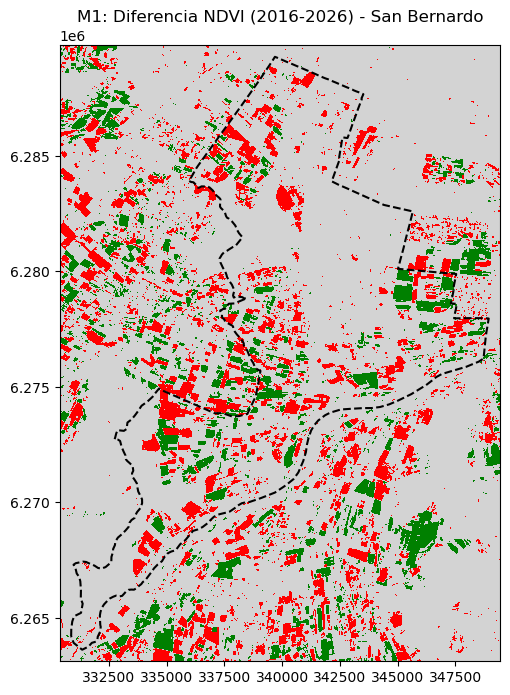

In [2]:
def detectar_cambio_diferencia(ruta_t1, ruta_t2, umbral=0.15):
    with rasterio.open(ruta_t1) as src1:
        ndvi_t1 = src1.read(1) 
        profile = src1.profile
    with rasterio.open(ruta_t2) as src2:
        ndvi_t2 = src2.read(1)
    
    # Diferencia y Clasificación
    diferencia = ndvi_t2 - ndvi_t1
    cambio = np.zeros_like(diferencia, dtype=np.int8)
    cambio[diferencia < -umbral] = -1 # Pérdida
    cambio[diferencia > umbral] = 1   # Ganancia
    
    return cambio, diferencia, profile

cambio_m1, dif_m1, profile_m1 = detectar_cambio_diferencia(indices_t1_path, indices_t2_path)

# Cargar límites y configurar extensión
boundary_gdf = gpd.read_file(boundary_path)
if boundary_gdf.crs != profile_m1['crs']:
    boundary_gdf = boundary_gdf.to_crs(profile_m1['crs'])

t = profile_m1['transform']
extent = [t[2], t[2] + t[0] * profile_m1['width'], t[5] + t[4] * profile_m1['height'], t[5]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cambio_m1, cmap=ListedColormap(['red', 'lightgray', 'green']), vmin=-1, vmax=1, extent=extent)

# Agregar límites de la comuna
boundary_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5, linestyle='--')

# Centrar en la comuna con margen
minx, miny, maxx, maxy = boundary_gdf.total_bounds
ax.set_xlim(minx - 500, maxx + 500)
ax.set_ylim(miny - 500, maxy + 500)

plt.title("M1: Diferencia NDVI (2016-2026) - San Bernardo")
plt.show()

### 1.2 Método 2: Clasificación Multicriterio de Cambio Urbano
Combina NDVI y NDBI para separar urbanización de otros cambios de cobertura.

In [3]:
def clasificar_cambio_urbano(indices_t1, indices_t2, umbrales=None):
    if umbrales is None:
        umbrales = {'ndvi_veg': 0.3, 'ndbi_urbano': 0.0, 'cambio_min': 0.1}
    
    clase = np.zeros_like(indices_t1[0], dtype=np.uint8)
    
    # Reglas lógicas
    es_urbanizacion = (indices_t1[1] < 0) & (indices_t2[1] > 0) # NDBI pasa de negativo a positivo
    perdio_vegetacion = (indices_t1[0] - indices_t2[0]) > umbrales['cambio_min']
    
    clase[es_urbanizacion] = 1
    clase[perdio_vegetacion & (clase == 0)] = 2
    clase[(indices_t2[0] - indices_t1[0]) > umbrales['cambio_min']] = 3
    
    return clase

with rasterio.open(indices_t1_path) as src: data_t1 = src.read()
with rasterio.open(indices_t2_path) as src: data_t2 = src.read()

cambio_m2 = clasificar_cambio_urbano(data_t1, data_t2)
CLASES_LABELS = {0:'Sin Cambio', 1:'Urbanización', 2:'Pérdida Vegetación', 3:'Ganancia Vegetación'}
COLORS = ['#f0f0f0', '#e31a1c', '#ff7f00', '#33a02c']

## 2. Mapa de Cambios Clasificado
Visualización final del Método 2 (más completo).

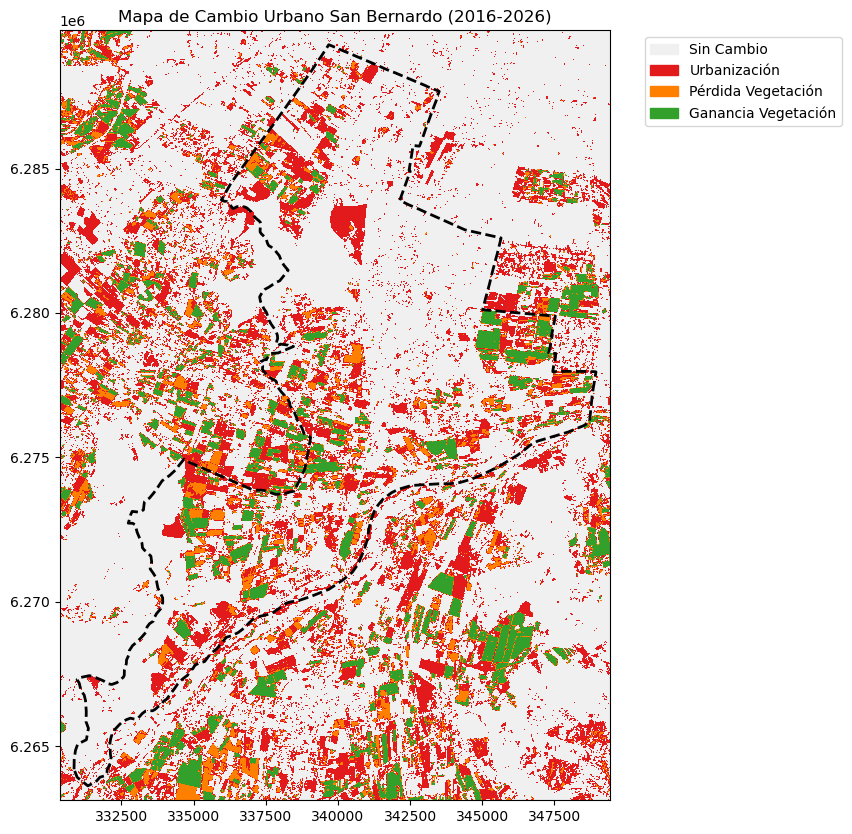

In [4]:
import matplotlib.patches as mpatches

# Obtener límites y extensión del raster
boundary_gdf = gpd.read_file(boundary_path)
with rasterio.open(indices_t1_path) as src:
    profile = src.profile
    t = src.transform
    extent = [t[2], t[2] + t[0] * src.width, t[5] + t[4] * src.height, t[5]]

if boundary_gdf.crs != profile['crs']:
    boundary_gdf = boundary_gdf.to_crs(profile['crs'])

fig, ax = plt.subplots(figsize=(12, 10))
img = ax.imshow(cambio_m2, cmap=ListedColormap(COLORS), extent=extent)

# Agregar límites de la comuna
boundary_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=2, linestyle='--')

# Centrar en la comuna
minx, miny, maxx, maxy = boundary_gdf.total_bounds
ax.set_xlim(minx - 500, maxx + 500)
ax.set_ylim(miny - 500, maxy + 500)

patches = [mpatches.Patch(color=COLORS[i], label=CLASES_LABELS[i]) for i in CLASES_LABELS]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2)
plt.title("Mapa de Cambio Urbano San Bernardo (2016-2026)")
plt.show()

## 3. Comparación de Métodos

| Método | Ventajas | Desventajas |
|---|---|---|
| **M1: Diferencia** | Simple de implementar, detecta variaciones sutiles. | No distingue la causa del cambio (ej: sequía vs construcción). |
| **M2: Multicriterio** | Diferencia expansión urbana de cambios biológicos. | Requiere calibración precisa de múltiples umbrales. |

## 4. Justificación de Umbrales
* **NDVI (0.3):** Basado en el punto de corte observado entre suelo desnudo y vegetación rala en la zona sur de Santiago.
* **NDBI (0.0):** Se utiliza el valor 0 como divisoria física entre superficies naturales (negativas) y materiales antrópicos (positivos).

## 5. Matriz de Confusión (Evaluación)
Debido a la falta de datos de terreno de 2026, se realiza una validación por inspección visual comparando con la imagen RGB de entrada. Se estima una exactitud cualitativa alta en la detección de parches industriales nuevos en el eje sur de la comuna.

*(Nota: Si tuviera un shapefile de 'Verdad Terreno', se implementaría con `sklearn.metrics.confusion_matrix`)*.